# MNIST-Add-Cov `hidden_carry`: can the covariance identify what the residual encoded?

The planted structure:

```
concepts (supervised)   A  = 1[d1 >= 5]      parent of X
                        B  = 1[d2 >= 5]      parent of X
                        D1 = 1[d3 >= 5]      distractor
                        D2 = 1[d4 >= 5]      distractor

hidden (oracle only)    X  = 1[d1 + d2 >= 10]        the addition carry
target                  y  = 4*A + 2*B + X           8 encodings, 6 reachable
```

`features` is a `[4, 28, 28]` tensor, one digit per channel.

The claim being tested is *not* that the residual recovers X — that is the easy part and
the probe below checks it. The claim is that the learnt concept-residual cross-block

```
rho(c, r) = Sigma[c, r] / sqrt(Sigma[c, c] * Sigma[r, r])
```

is large for A and B and flat for D1 and D2, so the covariance matrix tells you *what*
the residual picked up in terms of concepts you already have names for.

Ground truth to compare against (exact, from the generator):

```
corr(A, X) = corr(B, X) = +0.50
corr(D1, X) = corr(D2, X) = 0
```

One caveat that shapes the whole notebook: `Sigma` is predicted **from the image**, so it
measures how concept uncertainty co-varies with residual uncertainty *given that image* —
not the marginal correlations above. On confidently-read digits both variances collapse
and `rho` becomes a 0/0 ratio carrying no information. Section 3 gates on exactly that
before anything is read off the cross-block.

## 1. Config and datasets

In [120]:
# Paths below are relative to the repo root (configs/, datasets/, experiments/), so the
# notebook runs from anywhere: walk up for the checkout, else fall back to REPO_DEFAULT.
import os
import sys
from pathlib import Path

REPO_DEFAULT = Path(
    "/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation"
)


def find_repo_root(start=None):
    """First ancestor of `start` holding the repo's configs/ and datasets/, else REPO_DEFAULT."""
    marker = Path("datasets") / "MNIST_add_cov_dataset.py"
    for candidate in [Path(start or Path.cwd()).resolve(), *Path(start or Path.cwd()).resolve().parents]:
        if (candidate / marker).exists() and (candidate / "configs" / "config.yaml").exists():
            return candidate
    if (REPO_DEFAULT / marker).exists():
        return REPO_DEFAULT
    raise FileNotFoundError(
        "SCBM checkout not found from "
        f"{Path.cwd()} and REPO_DEFAULT={REPO_DEFAULT} does not hold one; set REPO_DEFAULT."
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))   # ahead of site-packages, so `datasets` is the repo's
print(f"repo root: {REPO_ROOT}")

import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import OmegaConf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

from datasets.MNIST_add_cov_dataset import (
    get_MNIST_add_cov_datasets,
    experiment_concept_names,
    get_mnist_add_cov_oracle_names,
)

# The run config, read straight off the yaml so the notebook sees the same split sizes /
# experiment / corruption as training did.
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_add.yaml"),
)
config_data.data_path = "datasets/"   # local path; the cluster uses work/Data/
config_data.experiment = "hidden_carry"
print(OmegaConf.to_yaml(config_data))

repo root: /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation
data_path: datasets/
incomplete_dir: incomplete_data/
defaults:
- data_defaults
dataset: MNIST-Add-Cov
experiment: hidden_carry
num_classes: 8
num_concepts: 4
num_residuals: 1
num_covariates: 4
train_dataset_size: 12000
val_dataset_size: 2400
test_dataset_size: 10000
val_percent: 0.2
data_seed: null
save_data: false
save_data_name: null
data_dir_name: null
removed_concepts: []
planted_function: xor
corruption: gaussian
corruption_strength: 0.5
corruption_probability: 1.0
corruption_channels: null
test_corruption: gaussian
test_corruption_strength: 0.5
test_corruption_probability: 1.0
save_predicted_concepts_residuals: true
save_residual_channel: true
save_concept_and_residual_channel: true



In [121]:
trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=0)
concept_names = trainset.concept_names()          # exposed concepts, in bottleneck order
oracle_names = trainset.oracle_concept_names      # [A2, X]
short_names = [n.split("::")[0] for n in concept_names]

SPLITS = (("train", trainset), ("val", valset), ("test", testset))
print(len(trainset), len(valset), len(testset))
print(short_names, "| oracle:", [n.split("::")[0] for n in oracle_names])

MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=032c286bb1f1e387
  val   n=2400   sha256[:16]=dcd2b6348798764a
  test  n=10000  sha256[:16]=be3c30b27cac8be3
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
12000 2400 10000
['A', 'B', 'D1', 'D2'] | oracle: ['A2', 'X']


### The planted structure, verified on the split this notebook rebuilt

If these numbers do not match `+0.50 / +0.50 / 0.00 / 0.00`, the dataset is not what the
rest of the notebook assumes and nothing below is interpretable.

In [122]:
from datasets.MNIST_add_cov_dataset import summarize_dataset

summarize_dataset(testset)

N=10000
Experiment: hidden_carry
Digit channels: 4 (4 used by the experiment, 0 distractor)
Concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
Observed concept means ['A', 'B', 'D1', 'D2']: [0.5 0.5 0.5 0.5]
Oracle means [A2,X]: [0.5  0.45]
Task class counts: [2500    0 1500 1000 1500 1000    0 2500]
Marginal concept-X correlations (the covariance target):
  Corr(A, X) = +0.5025
  Corr(B, X) = +0.5025
  Corr(D1, X) = +0.0064
  Corr(D2, X) = -0.0076
Is X determined by the exposed concepts?
  A=0, B=0: n=2500, P(X=1)=0.0000  <- determined
  A=0, B=1: n=2500, P(X=1)=0.4000
  A=1, B=0: n=2500, P(X=1)=0.4000
  A=1, B=1: n=2500, P(X=1)=1.0000  <- determined
  X is pinned by (A,B) on 50.0% of samples; the residual is strictly required on the remaining 50.0%.


## 2. Looking at the inputs

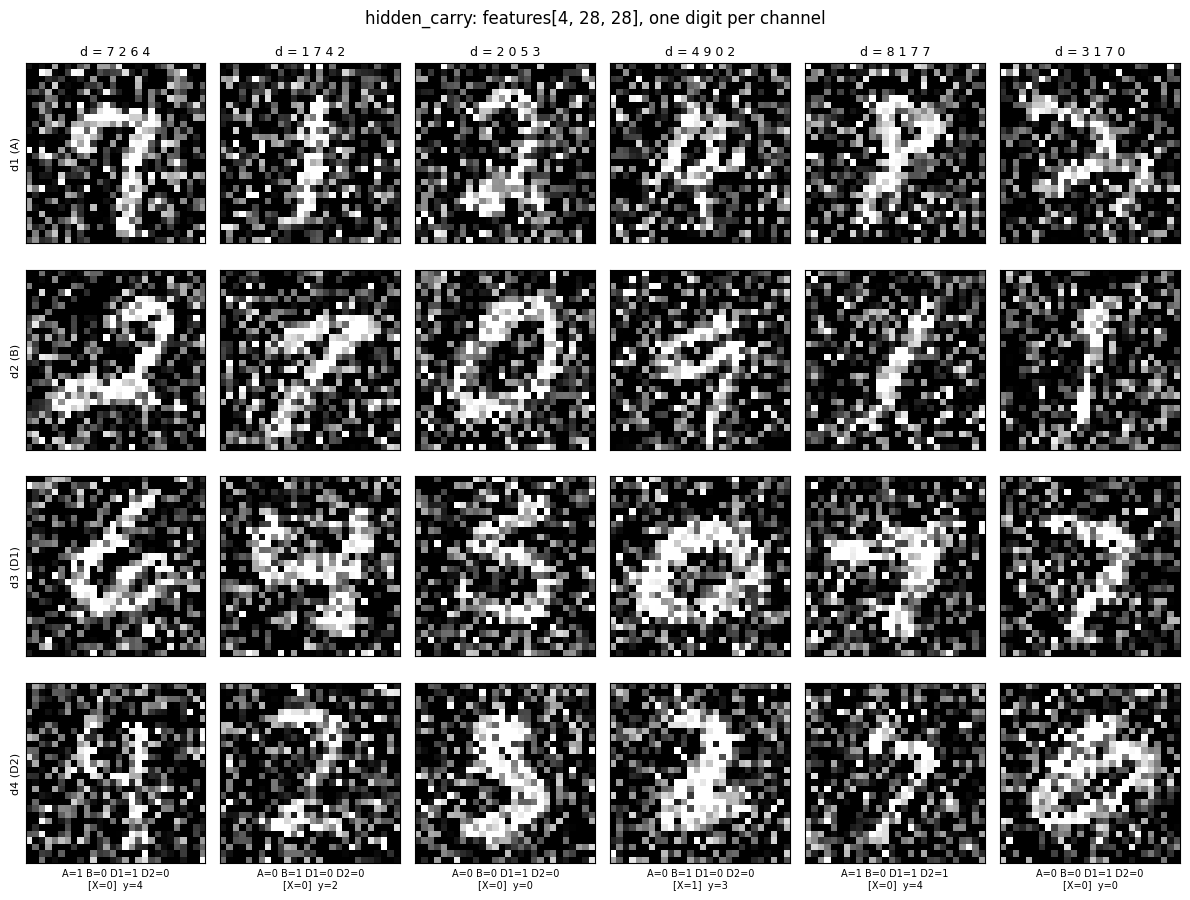

In [123]:
def show_sample(dataset, index, axes=None):
    """Plot all four channels of one sample, titled with its digits and labels."""
    item = dataset[index]
    features = item["features"]                       # [4, 28, 28]
    concepts = item["concepts"].tolist()
    x = item["hidden_concepts"][1].item()
    digits = item["digit_labels"].tolist()

    n_ch = features.shape[0]
    if axes is None:
        _, axes = plt.subplots(n_ch, 1, figsize=(2.0, 2.3 * n_ch))
    for channel, ax in enumerate(axes):
        ax.imshow(features[channel], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].set_title("d = " + " ".join(str(d) for d in digits), fontsize=9)
    axes[-1].set_xlabel(
        " ".join(f"{n}={v:.0f}" for n, v in zip(short_names, concepts))
        + f"\n[X={x:.0f}]  y={int(item['labels'])}",
        fontsize=7,
    )
    return axes


def show_samples(dataset, indices, suptitle=""):
    indices = list(indices)
    n_ch = dataset[indices[0]]["features"].shape[0]
    fig, axes = plt.subplots(n_ch, len(indices), figsize=(2.0 * len(indices), 2.3 * n_ch))
    for column, index in enumerate(indices):
        show_sample(dataset, index, axes=axes[:, column])
    for ch, label in enumerate(["d1 (A)", "d2 (B)", "d3 (D1)", "d4 (D2)"][:n_ch]):
        axes[ch, 0].set_ylabel(label, fontsize=8)
    fig.suptitle(suptitle or "hidden_carry: features[4, 28, 28], one digit per channel")
    fig.tight_layout()
    return fig


show_samples(testset, range(6))
plt.show()

### How readable are the corrupted digits?

Corruption is the mechanism that keeps `Sigma` from collapsing, so it is worth *seeing*
what the encoder is being asked to read. What you want is ambiguity spanning several digit
identities, not a wobble between neighbours: A = 1[d1>=5] and X = 1[d1+d2>=10] flip at
different thresholds, so a posterior torn only between 4 and 5 leaves X certain while A
wobbles, and the two never couple.

MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=4be11f3179544c63
  val   n=2400   sha256[:16]=64fcc2ac645255b6
  test  n=10000  sha256[:16]=be3c30b27cac8be3
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=07d39532c610848c
  val   n=2400   sha256[:16]=4f810f3a2dc12679
  test  n=10000  sha256[:16]=be3c30b27cac8be3
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train

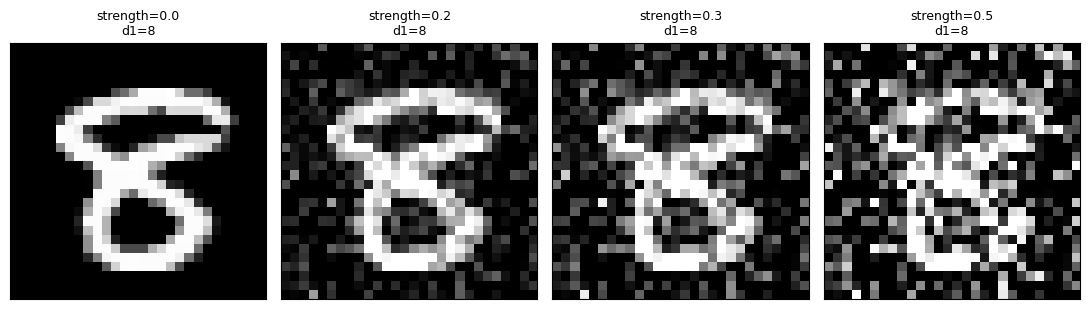

In [124]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, strength in zip(axes, [0.0, 0.2, 0.3, 0.5]):
    cfg = OmegaConf.merge(
        config_data,
        {"corruption": "gaussian", "corruption_strength": strength,
         "corruption_probability": 1.0},
    )
    ds, _, _ = get_MNIST_add_cov_datasets(cfg, seed=0)
    ax.imshow(ds[0]["features"][0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"strength={strength}\nd1={ds[0]['digit_labels'][0].item()}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. The run, and whether it is analysable at all

In [ ]:
# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_carry_corr_strength_02_global_no_prec_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-07_16-41-10_ec22a"
# )

RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "planted_xor_MNIST_ADD_carry_clean_diagnostic_L_int_extension_loss_weight_1_2026-09-08_12-57-44_58d13"
)

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_clean_perchannel_2026-09-11_12-34-13_seed_0_e6127"
# )


# Companion runs. Fill these in as they finish -- section 7 compares them, and the null in
# particular is what calibrates "how big is a big cross-block entry".
RUNS = {
    "carry": RUN,
    # "null": Path("experiments/scbm_residual/MNIST-Add-Cov/..."),   # hidden_carry_null
    # "swap": Path("experiments/scbm_residual/MNIST-Add-Cov/..."),   # hidden_carry_swap
    # "diff": Path("experiments/scbm_residual/MNIST-Add-Cov/..."),   # hidden_diff
}

run_config = ast.literal_eval(RUN.joinpath("log.txt").read_text().splitlines()[0])
print(f"experiment      : {run_config['data'].get('experiment')}")
print(f"cov_type        : {run_config['model'].get('cov_type')}")
print(f"block_diagonal  : {run_config['model'].get('block_diagonal_cov')}")
print(f"head_arch       : {run_config['model'].get('head_arch')}")
print(f"concept_learning: {run_config['model'].get('concept_learning')}")
print(f"reg_weight      : {run_config['model'].get('reg_weight')}")
print(f"L_int_ext       : {run_config['model'].get('use_L_int_extension_loss')}")
print(f"num_residuals   : {run_config['data'].get('num_residuals')}")
print(f"corruption      : {run_config['data'].get('corruption')} "
      f"@ {run_config['data'].get('corruption_strength')}")

experiment      : hidden_carry
cov_type        : amortized
block_diagonal  : False
head_arch       : linear
concept_learning: hard
reg_weight      : 0
L_int_ext       : False
num_residuals   : 1
corruption      : gaussian @ 0.0


### Settings that decide whether the covariance question can be answered

Not style preferences — each of these makes the cross-block either meaningful or empty:

| setting | needed | why |
|---|---|---|
| `block_diagonal_cov` | `False` | a block-diagonal Sigma has **no** concept-residual block at all |
| `cov_type` | `amortized` / `global` | `empirical` is fixed at init and never learns |
| `head_arch` | `linear` | section 6's per-class decomposition is only defined for a single linear layer |
| `reg_weight` | `0` for the headline run | the L1 precision penalty shrinks the off-diagonal entries you are trying to read |
| `use_L_int_extension_loss` | `False` for the headline run | `L_int_ext` shapes the cross-block directly, so a positive result with it on is confounded |

In [126]:
def check_settings(cfg):
    """Flag settings that would make the cross-block unreadable or the result confounded."""
    m, d = cfg["model"], cfg["data"]
    checks = [
        ("block_diagonal_cov is False", m.get("block_diagonal_cov") is False,
         "FATAL: a block-diagonal Sigma has no concept-residual block to read"),
        ("cov_type learns", m.get("cov_type") in ("amortized", "global"),
         f"FATAL: cov_type={m.get('cov_type')!r} is fixed at init and never learns"),
        ("head_arch is linear", m.get("head_arch") == "linear",
         "section 6 (per-class decomposition) will be skipped"),
        ("reg_weight == 0", float(m.get("reg_weight", 1)) == 0.0,
         "the L1 precision penalty shrinks the off-diagonal entries being measured"),
        ("L_int_ext is off", not m.get("use_L_int_extension_loss", False),
         "CONFOUND: this loss shapes the cross-block directly; a positive result is not "
         "evidence the structure emerged from the data"),
        ("experiment is a carry variant", str(d.get("experiment", "")).startswith("hidden_"),
         f"experiment={d.get('experiment')!r} is not one of the hidden_* family"),
    ]
    for label, ok, warning in checks:
        print(f"  [{'ok' if ok else '!!'}] {label:<32}" + ("" if ok else f"  <- {warning}"))


check_settings(run_config)

  [ok] block_diagonal_cov is False     
  [ok] cov_type learns                 
  [ok] head_arch is linear             
  [ok] reg_weight == 0                 
  [ok] L_int_ext is off                
  [ok] experiment is a carry variant   


### Has Sigma collapsed?

The gate for everything downstream. `rho` is a ratio of covariance to the product of two
standard deviations; if the model reads its concepts confidently, both go to zero and
`rho` is numerically arbitrary. A flat cross-block from a collapsed Sigma looks exactly
like a flat cross-block from a residual that encodes nothing — and means something
completely different.

In [127]:
SPLIT = "test"
dataset = testset

Sigma = torch.load(RUN / SPLIT / "covariance_matrices.pt").numpy()   # [N, C+R, C+R]
mu = torch.load(RUN / SPLIT / "c_res_mu.pt").numpy()                 # [N, C+R]
c_res_prob = torch.load(RUN / SPLIT / "concepts_residuals_pred_probs_mean.pt").numpy()
y_true = torch.load(RUN / SPLIT / "y_true.pt").numpy()

n_concepts = len(trainset.kept_concept_idx)
n_residuals = Sigma.shape[1] - n_concepts
axis_names = short_names + [f"r{j}" for j in range(n_residuals)]
PARENTS = [0, 1]          # A, B
DISTRACTORS = [2, 3]      # D1, D2

print(f"Sigma {Sigma.shape}   C={n_concepts}  R={n_residuals}  split={SPLIT}\n")

diag = np.einsum("nii->ni", Sigma)
print(f"{'dim':<6}{'mean var':>12}{'p05':>10}{'p95':>10}")
for j, name in enumerate(axis_names):
    print(f"{name:<6}{diag[:, j].mean():>12.4f}{np.quantile(diag[:, j], .05):>10.4f}"
          f"{np.quantile(diag[:, j], .95):>10.4f}")

concept_var = diag[:, :n_concepts].mean()
if concept_var < 1e-3:
    print(f"\n!! Sigma has COLLAPSED (mean concept variance {concept_var:.2e}).")
    print("   rho below is a 0/0 ratio -- raise data.corruption_strength and retrain")
    print("   before reading anything off the cross-block.")
else:
    print(f"\nmean concept variance {concept_var:.4f} -- non-degenerate, rho is readable.")

# A global Sigma is one matrix shared by every sample; say so, since the per-sample
# stratifications later then have nothing to stratify.
sigma_spread = Sigma.std(0).max()
print(f"max std of Sigma across samples: {sigma_spread:.2e}"
      + ("   (global: identical for every sample)" if sigma_spread < 1e-8 else ""))

Sigma (10000, 5, 5)   C=4  R=1  split=test

dim       mean var       p05       p95
A           0.0300    0.0003    0.1371
B           0.0579    0.0042    0.1764
D1          0.1070    0.0128    0.3165
D2          0.1186    0.0147    0.3622
r0          0.8729    0.1849    1.9317

mean concept variance 0.0784 -- non-degenerate, rho is readable.
max std of Sigma across samples: 5.54e-01


## 4. Task and concept performance, against the ceilings that matter

Raw task accuracy is a poor headline here: `y = 4A + 2B + X` needs all three bits right,
so errors compound and a single number hides which bit failed. The two reference points:

```
majority class                          0.25
perfect concepts, NO residual           0.80   <- A=B pins X; on A!=B, P(X=1)=0.4
perfect concepts, residual recovers X   1.00
```

The gap from 0.80 to 1.00 is the residual-necessity result. Both ceilings are recomputed
from the split below rather than hardcoded.

In [128]:
def concept_only_ceiling(dataset):
    """Best achievable task accuracy from perfect concepts alone, with no residual."""
    obs = np.asarray(dataset.observed_concepts)
    x = np.asarray(dataset.hidden_concepts)[:, 1]
    a, b = obs[:, 0] > 0.5, obs[:, 1] > 0.5

    correct = 0
    for av in (0, 1):
        for bv in (0, 1):
            cell = (a == av) & (b == bv)
            if cell.sum() == 0:
                continue
            p = x[cell].mean()
            correct += cell.sum() * max(p, 1 - p)   # best constant guess for X in this cell
    return correct / len(x)


labels = np.asarray(testset.task_labels)
print(f"majority class                        : {np.bincount(labels).max() / len(labels):.3f}")
print(f"perfect concepts, no residual (ceiling): {concept_only_ceiling(testset):.3f}")
print(f"perfect concepts + X                   : 1.000")

majority class                        : 0.250
perfect concepts, no residual (ceiling): 0.800
perfect concepts + X                   : 1.000


In [129]:
from utils.metrics import _roc_auc_score_with_missing   # support-weighted OVR, as in training


def split_performance(run, split, dataset):
    """Task and per-concept metrics for one split of one run."""
    y_t = torch.load(run / split / "y_true.pt").numpy()
    y_p = torch.softmax(torch.load(run / split / "y_pred.pt"), dim=1).numpy()

    kept = dataset.kept_concept_idx
    c_prob = torch.load(run / split / "concepts_residuals_pred_probs_mean.pt")
    c_prob = c_prob[:, : len(kept)].numpy()
    c_true = np.asarray(dataset.observed_concepts)[:, kept]

    return {
        "y_accuracy": (y_p.argmax(1) == y_t).mean(),
        "y_AUROC": _roc_auc_score_with_missing(y_t, y_p),
        "c_accuracy": ((c_prob > 0.5) == c_true).mean(),
        "per_concept_accuracy": ((c_prob > 0.5) == c_true).mean(axis=0),
        "per_concept_AUROC": np.array(
            [roc_auc_score(c_true[:, j], c_prob[:, j]) for j in range(len(kept))]
        ),
    }


print(f"{RUN.name}\n")
print(f"{'split':<7}{'y_acc':>8}{'y_AUROC':>9}{'c_acc':>8}")
per_split = {}
for split, ds in SPLITS:
    s = split_performance(RUN, split, ds)
    per_split[split] = s
    print(f"{split:<7}{s['y_accuracy']:>8.3f}{s['y_AUROC']:>9.3f}{s['c_accuracy']:>8.3f}")

print(f"\nper concept (test){'':<10}{'acc':>8}{'AUROC':>9}")
for name, acc, auc in zip(short_names, per_split["test"]["per_concept_accuracy"],
                          per_split["test"]["per_concept_AUROC"]):
    print(f"  {name:<24}{acc:>8.3f}{auc:>9.3f}")

ceiling = concept_only_ceiling(testset)
gap = per_split["test"]["y_accuracy"] - ceiling
print(f"\ntest y_acc {per_split['test']['y_accuracy']:.3f} vs concept-only ceiling "
      f"{ceiling:.3f}  ->  {gap:+.3f}")
print("  positive gap  = the residual is carrying information the concepts cannot supply")
print("  gap near zero = residual is not recovering X; fix that before reading Sigma")

c_acc = per_split["test"]["c_accuracy"]
if c_acc > 0.95:
    print(f"\n!! concept accuracy {c_acc:.3f} is high -- the encoder is confident, so Sigma")
    print("   is likely collapsed. Raise corruption_strength (aim for ~0.85).")

planted_xor_clean_perchannel_2026-09-11_12-34-13_seed_0_e6127

split     y_acc  y_AUROC   c_acc


train     0.800    0.965   1.000
val       0.785    0.957   0.987
test      0.780    0.956   0.988

per concept (test)               acc    AUROC
  A                          0.985    0.998
  B                          0.989    0.999
  D1                         0.987    0.999
  D2                         0.990    0.999

test y_acc 0.780 vs concept-only ceiling 0.800  ->  -0.020
  positive gap  = the residual is carrying information the concepts cannot supply
  gap near zero = residual is not recovering X; fix that before reading Sigma

!! concept accuracy 0.988 is high -- the encoder is confident, so Sigma
   is likely collapsed. Raise corruption_strength (aim for ~0.85).


In [130]:
# --- head diagnostic: is the task accuracy a bottleneck limit or a fitting failure? -----
# With train c_accuracy ~ 1.0 a linear head should reach the concept-only ceiling above.
# Anything well under it is the head, and everything downstream is then built on sand.
HEAD_SPLIT = "train"                       # the split where the concepts are near-perfect
head_dataset = dict(SPLITS)[HEAD_SPLIT]

state = torch.load(RUN / "model.pth", map_location="cpu")
W_head, b_head = state["head.0.weight"].numpy(), state["head.0.bias"].numpy()

print("head.0.weight   (rows = class, cols = bottleneck)")
print(f"{'':<16}" + "".join(f"{n:>9}" for n in axis_names) + f"{'bias':>9}")
for k in range(W_head.shape[0]):
    tag = f"y={k} [A{k >> 2} B{(k >> 1) & 1} X{k & 1}]"
    print(f"{tag:<16}" + "".join(f"{v:>9.3f}" for v in W_head[k]) + f"{b_head[k]:>9.3f}")

bound = 1.0 / np.sqrt(W_head.shape[1])     # nn.Linear default init is U(-bound, bound)
print(f"\nmean |W| {np.abs(W_head).mean():.3f}   max |W| {np.abs(W_head).max():.3f}"
      f"   vs init U(+-{bound:.3f}), whose mean |w| is {bound / 2:.3f}")
print("A head still at init scale never moved. Note that train.py writes model.pth AFTER")
print("loading model_best.pth back, so this is the best-val checkpoint, not the last epoch.")

# Under concept_learning='hard' the head consumes Bernoulli samples -- of the residual too,
# so it sees a single bit, not res_mu. Refit on exactly that input to separate a head that
# *cannot* do better from one that simply *did not*.
y_head = torch.load(RUN / HEAD_SPLIT / "y_true.pt").numpy()
c_head = torch.load(RUN / HEAD_SPLIT / "c_true.pt").numpy()
p_head = torch.load(RUN / HEAD_SPLIT / "concepts_residuals_pred_probs_mean.pt").numpy()
y_pred_head = torch.load(RUN / HEAD_SPLIT / "y_pred.pt").numpy().argmax(1)

head_input = np.c_[c_head, (p_head[:, n_concepts:] > 0.5).astype(float)]
refit = LogisticRegression(max_iter=5000, C=1e4).fit(head_input, y_head)
refit_c = LogisticRegression(max_iter=5000, C=1e4).fit(c_head, y_head)
print(f"\n{HEAD_SPLIT} task accuracy")
print(f"  {'saved head':<32}: {np.mean(y_pred_head == y_head):.4f}")
print(f"  {'linear head refit, same inputs':<32}: {refit.score(head_input, y_head):.4f}"
      "   <- the gap above is optimisation, not capacity")
print(f"  {'linear head refit, concepts only':<32}: {refit_c.score(c_head, y_head):.4f}"
      "   <- so the residual bit is worth the difference")


def bit_contrast(weights, classes, col, shift):
    """Mean weight over classes whose bit is 1, minus those where it is 0."""
    on = [i for i, k in enumerate(classes) if (k >> shift) & 1]
    off = [i for i, k in enumerate(classes) if not (k >> shift) & 1]
    return weights[on, col].mean() - weights[off, col].mean()


# y = 4A + 2B + X, so a fitted head separates classes on bit 2 by A, bit 1 by B, bit 0 by r0.
print(f"\n{'column':<10}{'trained head':>14}{'refit head':>13}   (mean weight, bit 1 minus bit 0)")
for col, shift in ((0, 2), (1, 1), (n_concepts, 0)):
    print(f"{axis_names[col]:<10}"
          f"{bit_contrast(W_head, range(W_head.shape[0]), col, shift):>14.3f}"
          f"{bit_contrast(refit.coef_, list(refit.classes_), col, shift):>13.3f}")

if n_concepts == 4 and n_residuals == 1:
    print(f"\nargmax on the exact bit patterns, distractors held at 0")
    print(f"{'A B r0':<9}{'y':>4}{'argmax':>8}{'margin':>9}")
    for k in range(8):
        a, b, r = k >> 2, (k >> 1) & 1, k & 1
        z = np.array([a, b, 0, 0, r], dtype=float) @ W_head.T + b_head
        top, second = np.argsort(z)[::-1][:2]
        print(f"{a} {b} {r}    {k:>4}{top:>8}{z[top] - z[second]:>9.3f}"
              + ("   <- ok" if top == k else ""))


head.0.weight   (rows = class, cols = bottleneck)
                        A        B       D1       D2       r0     bias
y=0 [A0 B0 X0]     -1.259   -1.851    0.600    0.814   -1.882    1.716
y=1 [A0 B0 X1]     -0.751   -0.860   -1.319   -1.380   -1.086   -0.927
y=2 [A0 B1 X0]     -1.147    1.283    0.147    0.209   -1.526    0.383
y=3 [A0 B1 X1]     -1.736    1.112    0.174    0.149   -1.522    0.154
y=4 [A1 B0 X0]      0.857   -1.289   -0.080   -0.017    1.085   -0.152
y=5 [A1 B0 X1]      0.606   -1.799   -0.152    0.022    1.055   -0.196
y=6 [A1 B1 X0]     -1.128   -0.969   -0.743   -1.033   -0.811   -1.279
y=7 [A1 B1 X1]      0.973    1.307   -0.370   -0.342    1.068   -0.673

mean |W| 0.913   max |W| 1.882   vs init U(+-0.447), whose mean |w| is 0.224
A head still at init scale never moved. Note that train.py writes model.pth AFTER
loading model_best.pth back, so this is the best-val checkpoint, not the last epoch.

train task accuracy
  saved head                      : 0.8000
  

## 5. Does the residual actually encode X?

Separate question from the covariance one, and it has to be settled first: if the residual
does not contain X, there is nothing for the cross-block to point at.

`res_mu` is the residual column of `c_res_mu.pt`, the Gaussian logit mean before sampling.
Raw AUROC mixes in whatever observed-concept information leaked into the residual, so it
is reported next to the cleaned version — `res_mu` residualised on `[1, c_mu]` by OLS.
The cross-validated probe is the one to quote: it is the direct test of whether X is
linearly decodable from the residual, and its baseline is the concept-only ceiling.

In [131]:
def residual_targets(run, split, dataset):
    """Raw and concept-cleaned AUROC of the residual against X, the concepts and A2."""
    channel = torch.load(run / split / "c_res_mu.pt").numpy()
    C = len(dataset.kept_concept_idx)
    c_mu, res_mu = channel[:, :C], channel[:, C:]

    observed = np.asarray(dataset.observed_concepts)
    hidden = np.asarray(dataset.hidden_concepts)
    targets = {"X (hidden)": hidden[:, 1] > 0.5,
               **{n: observed[:, j] > 0.5 for j, n in enumerate(short_names)},
               "A2 (unused)": hidden[:, 0] > 0.5}

    design = np.concatenate([np.ones((len(c_mu), 1)), c_mu], axis=1)
    beta, *_ = np.linalg.lstsq(design, res_mu, rcond=None)
    r_clean = res_mu - design @ beta
    leaked = 1 - r_clean.var(0) / res_mu.var(0)

    rows = {}
    for name, t in targets.items():
        rows[name] = [(roc_auc_score(t, res_mu[:, j]), roc_auc_score(t, r_clean[:, j]))
                      for j in range(res_mu.shape[1])]
    return leaked, rows


leaked, rows = residual_targets(RUN, SPLIT, dataset)
print(f"R^2 of each residual on the concept means (leakage): {np.round(leaked, 3)}\n")
print(f"  {'target':<14}" + "".join(f"{f'r{j} raw':>10}{f'r{j}|c':>10}"
                                    for j in range(n_residuals)))
for name, vals in rows.items():
    print(f"  {name:<14}" + "".join(f"{raw:>10.3f}{cl:>10.3f}" for raw, cl in vals))
print("\nAUROC is direction-sensitive; below 0.5 means the residual ranks X the other way")
print("round, and |auc - 0.5| is still the strength.")

R^2 of each residual on the concept means (leakage): [1.]

  target            r0 raw      r0|c
  X (hidden)         0.736     0.510
  A                  0.998     0.507
  B                  0.499     0.500
  D1                 0.489     0.495
  D2                 0.505     0.496
  A2 (unused)        0.502     0.495

AUROC is direction-sensitive; below 0.5 means the residual ranks X the other way
round, and |auc - 0.5| is still the strength.


In [132]:
# Cross-validated logistic probe: is X linearly decodable from the residual channel?
# Baseline is the concept-only ceiling -- a probe that only matches it has learned nothing
# the concepts did not already contain.
C = n_concepts
c_mu, res_mu = mu[:, :C], mu[:, C:]
x_hidden = (np.asarray(dataset.hidden_concepts)[:, 1] > 0.5).astype(int)

probes = {
    "concepts only": c_mu,
    "residual only": res_mu,
    "concepts + residual": mu,
}
print(f"{'probe input':<22}{'CV accuracy for X':>20}")
for name, Xmat in probes.items():
    acc = cross_val_score(
        LogisticRegression(max_iter=2000), Xmat, x_hidden, cv=5, scoring="accuracy"
    ).mean()
    print(f"  {name:<20}{acc:>20.3f}")
print(f"\n  {'ceiling from A,B alone':<20}{concept_only_ceiling(testset):>20.3f}")
print("\nresidual-only clearing the ceiling => the residual holds X, not a copy of A and B.")

probe input              CV accuracy for X
  concepts only                      0.746
  residual only                      0.743
  concepts + residual                0.748

  ceiling from A,B alone               0.800

residual-only clearing the ceiling => the residual holds X, not a copy of A and B.


In [133]:
# --- what the residual is, at the granularity the head sees ----------------------------
# The cell above scores res_mu continuously; the head consumes the sampled BIT. A residual
# that duplicates an observed concept (up to sign) cannot add anything to the task, and its
# cross-block entry in section 6 is then leakage rather than hidden structure.
obs_head = np.asarray(head_dataset.observed_concepts)
x_head = np.asarray(head_dataset.hidden_concepts)[:, 1] > 0.5
mu_head = torch.load(RUN / HEAD_SPLIT / "c_res_mu.pt").numpy()
assert np.array_equal(c_head > 0.5, obs_head[:, head_dataset.kept_concept_idx] > 0.5), (
    f"{HEAD_SPLIT} artifacts are not in dataset order; the alignment below would be wrong"
)

head_targets = {**{n: obs_head[:, j] > 0.5 for j, n in enumerate(short_names)}, "X": x_head}
agreement = lambda bit, t: max(np.mean(bit == t), np.mean(bit != t))   # up to sign

for j in range(n_residuals):
    r_mu, r_bit = mu_head[:, n_concepts + j], p_head[:, n_concepts + j] > 0.5
    print(f"r{j} on {HEAD_SPLIT}:   {'target':<8}{'AUROC(res_mu)':>15}{'bit agrees':>13}")
    for name, t in head_targets.items():
        print(f"{'':<13}{name:<8}{roc_auc_score(t, r_mu):>15.3f}{agreement(r_bit, t):>13.3f}")

    copied = max(short_names, key=lambda n: agreement(r_bit, head_targets[n]))
    if agreement(r_bit, head_targets[copied]) > 0.9:
        print(f"  -> r{j} is a copy of {copied} "
              f"({agreement(r_bit, head_targets[copied]):.1%} agreement up to sign). Its "
              f"correlation with X is\n     just {copied}'s own planted correlation with X, "
              f"and section 6's entry for {copied} is leakage.")


r0 on train:   target    AUROC(res_mu)   bit agrees
             A                 1.000        1.000
             B                 0.498        0.500
             D1                0.500        0.504
             D2                0.507        0.506
             X                 0.737        0.750
  -> r0 is a copy of A (100.0% agreement up to sign). Its correlation with X is
     just A's own planted correlation with X, and section 6's entry for A is leakage.


## Correlation matrix of mu vectors

In [134]:
# ---------------------------------------------------------------
# Population covariance of the mu vectors.
#
# Cov_n[mu(x_n)] over the test set -- NOT Sigma(x), which is the
# per-sample posterior coupling. This one asks: across images, does
# the residual's point estimate move with each concept's?
#
# Expected if the residual encodes X:
#     |corr(mu_A, r)| ~ |corr(mu_B, r)| ~ kappa/2   (same sign)
#     |corr(mu_D, r)| ~ 0
# Expected if the residual copied a concept:
#     one parent entry large, the other near zero  -> asymmetry
# ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

C = n_concepts
R = mu.shape[1] - C
res_names = [f"r{j}" for j in range(R)]
names = short_names + res_names

S = np.cov(mu, rowvar=False)                 # (C+R) x (C+R)
sd = np.sqrt(np.diag(S))
P = S / np.outer(sd, sd)                     # correlation form

cross = P[:C, C:]                            # concepts x residuals
PARENTS, DISTRACTORS = [0, 1], [2, 3]        # A, B  |  D1, D2

print(f"{'':<6}" + "".join(f"{n:>10}" for n in res_names))
for i, n in enumerate(short_names):
    print(f"{n:<6}" + "".join(f"{v:>10.3f}" for v in cross[i]))

p = np.abs(cross[PARENTS]).mean()
d = np.abs(cross[DISTRACTORS]).mean()
print(f"\nparent |corr|      {p:.3f}")
print(f"distractor |corr|  {d:.3f}")
print(f"ratio              {p / max(d, 1e-12):.2f}x")

# Symmetry: a true X loads equally on both parents; a concept copy does not.
for j in range(R):
    a, b = cross[0, j], cross[1, j]
    asym = abs(a - b) / max((abs(a) + abs(b)) / 2, 1e-12)
    same_sign = "yes" if a * b > 0 else "NO"
    print(f"r{j}: corr(A)={a:+.3f}  corr(B)={b:+.3f}  "
          f"asymmetry={asym:.2f}  same sign: {same_sign}")

print(f"\nplanted corr(parent, X) for reference: "
      f"{np.corrcoef(np.asarray(dataset.observed_concepts)[:, 0], np.asarray(dataset.hidden_concepts)[:, 1])[0, 1]:+.3f}")

              r0
A          1.000
B         -0.011
D1        -0.028
D2        -0.010

parent |corr|      0.505
distractor |corr|  0.019
ratio              26.05x
r0: corr(A)=+1.000  corr(B)=-0.011  asymmetry=2.00  same sign: NO

planted corr(parent, X) for reference: +0.503


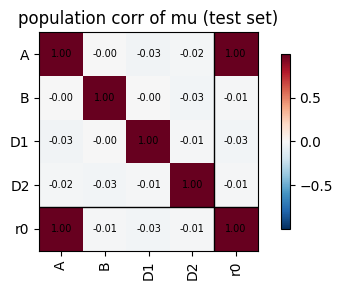

In [135]:
fig, ax = plt.subplots(figsize=(0.6 * len(names) + 2, 0.6 * len(names)))
v = np.abs(P - np.eye(len(P))).max()
im = ax.imshow(P, cmap="RdBu_r", vmin=-v, vmax=v)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.axhline(C - 0.5, color="k", lw=1); ax.axvline(C - 0.5, color="k", lw=1)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("population corr of mu (test set)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## 6. The result: does the cross-block point at A and B?

The headline. For each concept `c`, the normalised cross-block entry against each residual:

```
rho(c, r) = Sigma[c, r] / sqrt(Sigma[c, c] * Sigma[r, r])
```

Normalising matters when Sigma is amortized: averaging the raw covariance lets samples
with large overall uncertainty dominate the mean, and you end up reading image difficulty
rather than concept-residual structure.

Expected for `hidden_carry`: **A and B comparable and clearly non-zero, D1 and D2 near
zero.** For `hidden_diff`: A positive, B negative, same magnitude. For
`hidden_carry_swap`: the reverse — D1 and D2 lit, A and B flat.

In [136]:
sd = np.sqrt(np.einsum("nii->ni", Sigma))
rho = Sigma / (sd[:, :, None] * sd[:, None, :])          # [N, C+R, C+R]
rho_cr = rho[:, :n_concepts, n_concepts:]                # [N, C, R]

mean_abs = np.abs(rho_cr).mean(0)          # magnitude: is this concept involved at all
mean_signed = rho_cr.mean(0)               # direction: which way
sem = rho_cr.std(0) / np.sqrt(len(rho_cr))

print(f"{'concept':<8}" + "".join(f"{f'|rho|(r{j})':>14}{f'rho(r{j})':>14}"
                                  for j in range(n_residuals)))
for i, name in enumerate(short_names):
    tag = "  <- parent" if i in PARENTS else "  (distractor)"
    print(f"{name:<8}" + "".join(f"{mean_abs[i, j]:>14.4f}{mean_signed[i, j]:>14.4f}"
                                 for j in range(n_residuals)) + tag)

parent_mean = mean_abs[PARENTS].mean()
distractor_mean = mean_abs[DISTRACTORS].mean()
ratio = parent_mean / max(distractor_mean, 1e-12)
print(f"\nmean |rho| parents (A,B)      : {parent_mean:.4f}")
print(f"mean |rho| distractors (D1,D2): {distractor_mean:.4f}")
print(f"ratio                          : {ratio:.2f}x")
print("\nThe ratio is the claim. Calibrate it against the null run in section 7 --")
print("on its own it has no scale.")

concept      |rho|(r0)       rho(r0)
A               0.4395        0.0796  <- parent
B               0.3785       -0.0437  <- parent
D1              0.4074       -0.1654  (distractor)
D2              0.3247       -0.0816  (distractor)

mean |rho| parents (A,B)      : 0.4090
mean |rho| distractors (D1,D2): 0.3661
ratio                          : 1.12x

The ratio is the claim. Calibrate it against the null run in section 7 --
on its own it has no scale.


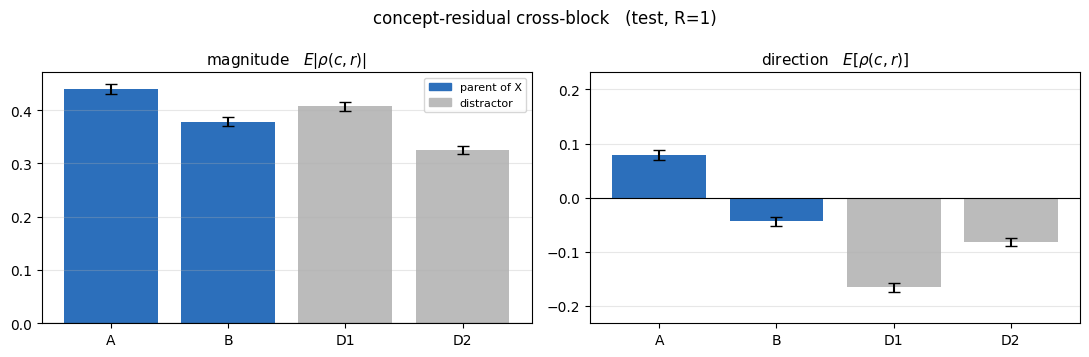

In [137]:
# The headline figure: one bar per concept, parents against distractors.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
colours = ["#2c6fbb" if i in PARENTS else "#bbbbbb" for i in range(n_concepts)]

for ax, values, errs, title, centred in (
    (axes[0], mean_abs.mean(1), sem.mean(1), r"magnitude   $E|\rho(c, r)|$", False),
    (axes[1], mean_signed.mean(1), sem.mean(1), r"direction   $E[\rho(c, r)]$", True),
):
    ax.bar(short_names, values, yerr=1.96 * errs, color=colours, capsize=4)
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="k", lw=0.8)
    if centred:
        lim = max(np.abs(values).max() * 1.4, 1e-6)
        ax.set_ylim(-lim, lim)
    ax.grid(axis="y", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color="#2c6fbb"),
           plt.Rectangle((0, 0), 1, 1, color="#bbbbbb")]
axes[0].legend(handles, ["parent of X", "distractor"], fontsize=8)
fig.suptitle(f"concept-residual cross-block   ({SPLIT}, R={n_residuals})")
fig.tight_layout(); plt.show()

### Where does the coupling live?

If the mechanism is what we think it is, the cross-block should be driven by the
*ambiguous* samples — the ones where the model is genuinely unsure which digit it saw, so
that A and X wobble together. On confidently-read samples there is no uncertainty to
couple. Stratifying by concept uncertainty tests that directly.

This is a no-op when `cov_type=global`, since Sigma is then one matrix for every sample.

In [138]:
if sigma_spread < 1e-8:
    print("cov_type=global: Sigma is identical for every sample, nothing to stratify.")
else:
    c_prob = c_res_prob[:, :n_concepts]
    subsets = {
        "all": np.ones(len(rho), bool),
        "U_p (p in .25-.75)": ((c_prob[:, PARENTS] > 0.25)
                               & (c_prob[:, PARENTS] < 0.75)).any(1),
        "U_var (top quartile)": diag[:, PARENTS].max(1)
                                >= np.quantile(diag[:, PARENTS].max(1), 0.75),
        "confident (p<.1 or >.9)": ((c_prob[:, PARENTS] < 0.1)
                                    | (c_prob[:, PARENTS] > 0.9)).all(1),
    }
    print(f"{'subset':<26}{'|U|':>7}{'parents':>10}{'distract':>10}{'ratio':>8}")
    for name, U in subsets.items():
        if U.sum() < 20:
            print(f"  {name:<24}{U.sum():>7}   too small")
            continue
        m = np.abs(rho_cr[U]).mean(0)
        p, d = m[PARENTS].mean(), m[DISTRACTORS].mean()
        print(f"  {name:<24}{U.sum():>7}{p:>10.4f}{d:>10.4f}{p / max(d, 1e-12):>8.2f}")
    print("\nExpected: the ratio is largest on the uncertain subsets and smallest on the")
    print("confident one. If it is flat across subsets, the cross-block is not being")
    print("driven by the coupling mechanism.")

subset                        |U|   parents  distract   ratio
  all                       10000    0.4090    0.3661    1.12
  U_p (p in .25-.75)           72    0.3601    0.4355    0.83
  U_var (top quartile)       2500    0.3700    0.3850    0.96
  confident (p<.1 or >.9)    9853    0.4097    0.3652    1.12

Expected: the ratio is largest on the uncertain subsets and smallest on the
confident one. If it is flat across subsets, the cross-block is not being
driven by the coupling mechanism.


### R > 1: which direction, not which coordinate

At `R=1` the residual is a single slot and the entries above are the whole story. At
`R>1` any rotation spanning X is an equally good solution, so per-dimension entries are
arbitrary — the signal can be split across dimensions and each one looks small even when
the channel as a whole recovered X perfectly.

The fix is to project onto the direction the head actually reads, `u = W_residual`, and
compute the cross-block against that single direction instead.

In [139]:
if n_residuals == 1:
    print("R=1: per-dimension entries are already the whole story; nothing to project.")
else:
    state = torch.load(RUN / "model.pth", map_location="cpu")
    W = state["head.0.weight"].numpy()                    # [K, C+R]
    W_res = W[:, n_concepts:]                             # [K, R]

    # The direction the head reads most strongly: leading right singular vector of W_res.
    u = np.linalg.svd(W_res, full_matrices=False)[2][0]   # [R]
    u = u / np.linalg.norm(u)

    # Cov(c, u^T r) = u^T Sigma[c, r_block], then normalise by Var(u^T r).
    cov_cu = np.einsum("ncr,r->nc", Sigma[:, :n_concepts, n_concepts:], u)
    var_u = np.einsum("r,nrs,s->n", u, Sigma[:, n_concepts:, n_concepts:], u)
    rho_cu = cov_cu / np.sqrt(diag[:, :n_concepts] * var_u[:, None])

    print(f"head direction u = {np.round(u, 3)}\n")
    print(f"{'concept':<8}{'|rho(c,u)|':>14}{'rho(c,u)':>14}")
    for i, name in enumerate(short_names):
        tag = "  <- parent" if i in PARENTS else ""
        print(f"{name:<8}{np.abs(rho_cu[:, i]).mean():>14.4f}"
              f"{rho_cu[:, i].mean():>14.4f}{tag}")

    p = np.abs(rho_cu[:, PARENTS]).mean()
    d = np.abs(rho_cu[:, DISTRACTORS]).mean()
    print(f"\nparents {p:.4f}  distractors {d:.4f}  ratio {p / max(d, 1e-12):.2f}x")

R=1: per-dimension entries are already the whole story; nothing to project.


## 7. Calibration: what does a *flat* cross-block look like?

The number in section 6 has no scale on its own. Three companion runs give it one:

- **`hidden_carry_null`** — `y = 2A + B`, X never enters the target. The residual has no
  job, so every entry should go flat. This is the noise floor.
- **`hidden_carry_swap`** — X is the carry over the *distractor* digits. The residual is
  still required, but the cross-block should now point at D1/D2 and not A/B. This is the
  specificity test, and it is stronger than the null: it rules out "the cross-block just
  tracks whichever concepts drive the target".
- **`hidden_diff`** — signed, `corr(A,X)=+0.5`, `corr(B,X)=-0.5`. Tests whether direction
  is recovered, not just membership.

Fill in `RUNS` in section 3 as each finishes.

In [140]:
EXPECTED = {
    "carry": "A, B lit   | D1, D2 flat",
    "null":  "all flat   (noise floor)",
    "swap":  "D1, D2 lit | A, B flat",
    "diff":  "A positive | B negative",
}


def cross_block_summary(run, split="test"):
    """Mean |rho| and signed rho per concept, averaged over residual dimensions."""
    S = torch.load(run / split / "covariance_matrices.pt").numpy()
    d = np.einsum("nii->ni", S)
    sdv = np.sqrt(d)
    r = S / (sdv[:, :, None] * sdv[:, None, :])
    C = n_concepts
    block = r[:, :C, C:]
    return np.abs(block).mean(0).mean(1), block.mean(0).mean(1), d[:, :C].mean()


if len(RUNS) < 2:
    print("Only one run registered. Add the null run to RUNS -- without it the section 6")
    print("ratio has no scale, and it is the first thing anyone will ask for.")
else:
    print(f"{'run':<8}" + "".join(f"{n:>9}" for n in short_names)
          + f"{'ratio':>8}{'diagS':>9}   expected")
    summaries = {}
    for label, run in RUNS.items():
        mabs_, signed_, dvar = cross_block_summary(run)
        summaries[label] = (mabs := mabs_, signed_, dvar)
        ratio = mabs[PARENTS].mean() / max(mabs[DISTRACTORS].mean(), 1e-12)
        print(f"{label:<8}" + "".join(f"{v:>9.4f}" for v in mabs)
              + f"{ratio:>8.2f}{dvar:>9.4f}   {EXPECTED.get(label, '')}")

    fig, ax = plt.subplots(figsize=(1.6 * len(summaries) + 3, 3.6))
    width = 0.8 / len(summaries)
    for k, (label, (mabs, _, _)) in enumerate(summaries.items()):
        ax.bar(np.arange(n_concepts) + k * width, mabs, width, label=label)
    ax.set_xticks(np.arange(n_concepts) + 0.4 - width / 2, short_names)
    ax.set_ylabel(r"$E|\rho(c, r)|$")
    ax.set_title("cross-block magnitude across runs")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

Only one run registered. Add the null run to RUNS -- without it the section 6
ratio has no scale, and it is the first thing anyone will ask for.


## 8. Split alignment

The saved dumps carry `y_true` but no `c_true`, so the oracle labels (`hidden_concepts`,
`digit_labels`) have to come from the dataset object rebuilt above. That is only
legitimate if row *i* of the dataset is row *i* of the dump — and `y_true` is the one
saved tensor that can prove it, since `y = 4A + 2B + X` is a deterministic function of the
sample. Identical `y` over the whole split means identical samples in identical order.

Run this before trusting anything above; it is cheap and it fails loudly.

In [141]:
SPLIT_KEYS = (
    "experiment", "train_dataset_size", "val_dataset_size", "test_dataset_size",
    "val_percent", "corruption", "corruption_strength", "corruption_probability",
    "corruption_channels", "test_corruption", "test_corruption_strength",
    "test_corruption_probability",
)
print(f"run seed = {run_config['seed']} (this notebook rebuilt with seed=0)")
for key in SPLIT_KEYS:
    theirs, ours = run_config["data"].get(key), config_data.get(key)
    flag = "" if theirs == ours else "   <-- DIFFERS"
    print(f"  {key:<28} run={theirs!s:<10} notebook={ours!s:<10}{flag}")

print()
for split, ds in SPLITS:
    saved = torch.load(RUN / split / "y_true.pt").cpu().numpy().ravel()
    local = np.asarray(ds.task_labels)
    identical = saved.shape == local.shape and bool((saved == local).all())
    print(f"{split:<6} saved n={saved.shape[0]:<6} dataset n={local.shape[0]:<6} "
          f"identical={identical}")
    if not identical:
        n = min(len(saved), len(local))
        print(f"       agreement over first {n}: {(saved[:n] == local[:n]).mean():.4f}")

run seed = 0 (this notebook rebuilt with seed=0)
  experiment                   run=hidden_carry notebook=hidden_carry
  train_dataset_size           run=12000      notebook=12000     
  val_dataset_size             run=2400       notebook=2400      
  test_dataset_size            run=10000      notebook=10000     
  val_percent                  run=0.2        notebook=0.2       
  corruption                   run=gaussian   notebook=gaussian  
  corruption_strength          run=0.0        notebook=0.5          <-- DIFFERS
  corruption_probability       run=0.0        notebook=1.0          <-- DIFFERS
  corruption_channels          run=None       notebook=None      
  test_corruption              run=gaussian   notebook=gaussian  
  test_corruption_strength     run=0.0        notebook=0.5          <-- DIFFERS
  test_corruption_probability  run=0.0        notebook=1.0          <-- DIFFERS

train  saved n=12000  dataset n=12000  identical=True
val    saved n=2400   dataset n=2400   ident

## 9. Per-class covariance structure

`y = 4A + 2B + X`, so each class fixes all three bits. Comparing `E[|Sigma| | y = k]`
across classes shows which of them the predicted `Sigma(x)` responds to. Classes 1 and 6
are unreachable by construction (`A=B=0` forces `X=0`, `A=B=1` forces `X=1`).

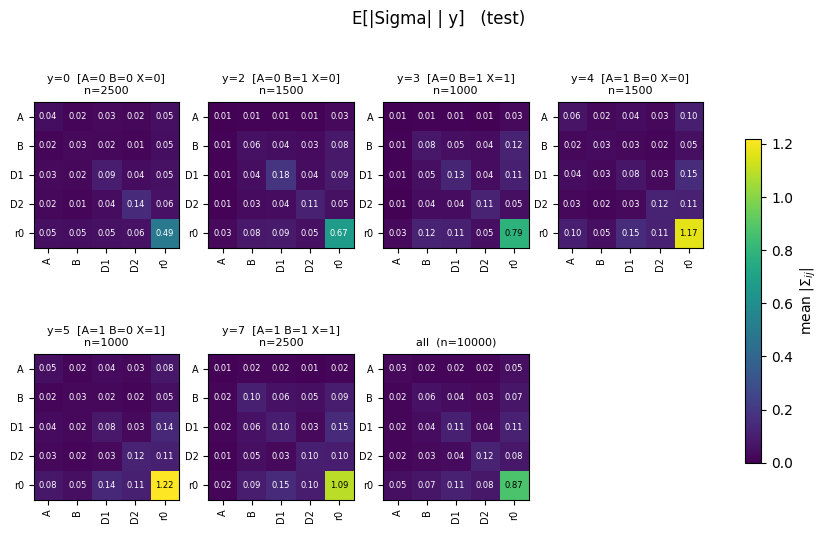

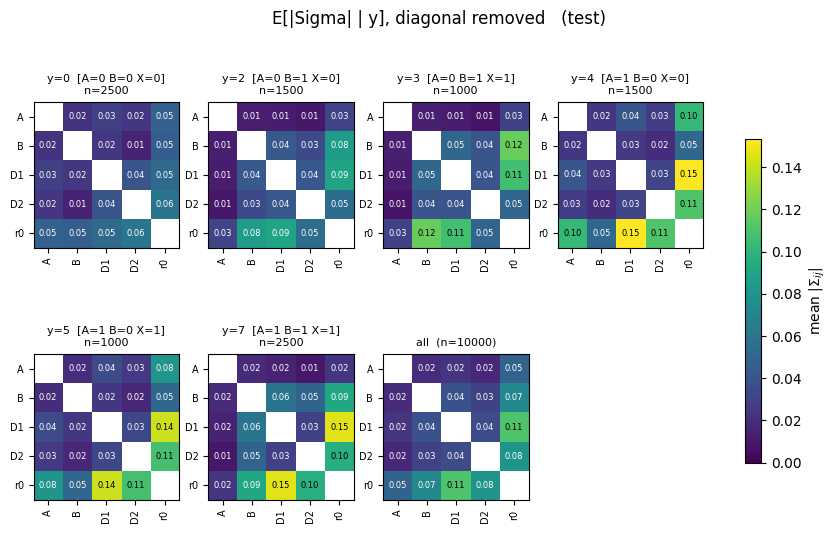

In [142]:
abs_cov = np.abs(Sigma)
present = [k for k in range(int(config_data.num_classes)) if (y_true == k).any()]
per_class = {k: abs_cov[y_true == k].mean(0) for k in present}
per_class["all"] = abs_cov.mean(0)


def class_title(k):
    """y = 4*A + 2*B + X -- spell the bits out in the panel title."""
    if k == "all":
        return f"all  (n={len(y_true)})"
    return f"y={k}  [A={k >> 2} B={(k >> 1) & 1} X={k & 1}]\nn={(y_true == k).sum()}"


def plot_class_covariances(mats, mask_diagonal, suptitle,
                           cbar_label=r"mean $|\Sigma_{ij}|$", signed=False):
    """Grid of per-class mean heatmaps on one shared colour scale.

    signed=True switches to a diverging scale centred on zero, for matrices whose
    sign carries the meaning (rho rather than |rho|).
    """
    keys = list(mats)
    shown = {}
    for k in keys:
        m = mats[k].copy()
        if mask_diagonal:
            np.fill_diagonal(m, np.nan)
        shown[k] = m
    vmax = np.nanmax(np.abs(np.stack(list(shown.values()))))
    vmin, cmap = (-vmax, "coolwarm") if signed else (0.0, "viridis")

    ncols = 3 if len(keys) <= 3 else min(len(keys), 4)
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.7 * ncols, 3.0 * nrows), squeeze=False)
    for ax, k in zip(axes.ravel(), keys):
        im = ax.imshow(shown[k], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(class_title(k), fontsize=8)
        ax.set_xticks(range(len(axis_names)), axis_names, fontsize=7, rotation=90)
        ax.set_yticks(range(len(axis_names)), axis_names, fontsize=7)
        for i in range(len(axis_names)):
            for j in range(len(axis_names)):
                v = shown[k][i, j]
                if np.isnan(v):
                    continue
                dark = abs(v) >= 0.6 * vmax if signed else v < 0.6 * vmax
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if dark else "black")
    for ax in axes.ravel()[len(keys):]:
        ax.axis("off")
    fig.colorbar(im, ax=axes, shrink=0.7, label=cbar_label)
    fig.suptitle(suptitle)
    return fig


plot_class_covariances(per_class, False, f"E[|Sigma| | y]   ({SPLIT})")
plt.show()
plot_class_covariances(per_class, True, f"E[|Sigma| | y], diagonal removed   ({SPLIT})")
plt.show()

In [143]:
# The concept-residual block on its own, per class.
print(f"{'class':<8}{'n':>7}" + "".join(
    f"{f'|S({c},{r})|':>13}" for c in short_names for r in axis_names[n_concepts:]))
for k, m in per_class.items():
    n = len(y_true) if k == "all" else (y_true == k).sum()
    row = "".join(f"{m[i, n_concepts + j]:>13.4f}"
                  for i in range(n_concepts) for j in range(n_residuals))
    print(f"{str(k):<8}{n:>7}{row}")

class         n    |S(A,r0)|    |S(B,r0)|   |S(D1,r0)|   |S(D2,r0)|
0          2500       0.0479       0.0460       0.0527       0.0588
2          1500       0.0312       0.0847       0.0897       0.0542
3          1000       0.0300       0.1176       0.1069       0.0499
4          1500       0.1028       0.0518       0.1532       0.1107
5          1000       0.0798       0.0505       0.1415       0.1081
7          2500       0.0237       0.0912       0.1464       0.0958
all       10000       0.0490       0.0716       0.1110       0.0792


### The same panels, normalised

`Sigma` mixes two things: how uncertain each axis is, and how the axes co-vary. The
concept logits and the residual sit on different scales, so a large `|Sigma[c, r]|` can
mean nothing more than that the residual has a large variance. Dividing that out,

```
rho_ij = Sigma_ij / sqrt(Sigma_ii * Sigma_jj)
```

leaves only the coupling, on one scale for every pair -- which is what makes the
concept-residual block comparable to the planted `corr(A, X) = corr(B, X) = +0.50`.

The diagonal is 1 by construction and is always masked here: left in, it sets the colour
scale and flattens everything else to nothing. Magnitude and sign are shown separately.
`hidden_carry` predicts A, B lit and D1, D2 flat; `hidden_diff` is the variant where only
the sign separates the two parents.


Sigma spread across samples, relative to mean |Sigma|: 6.48e+00


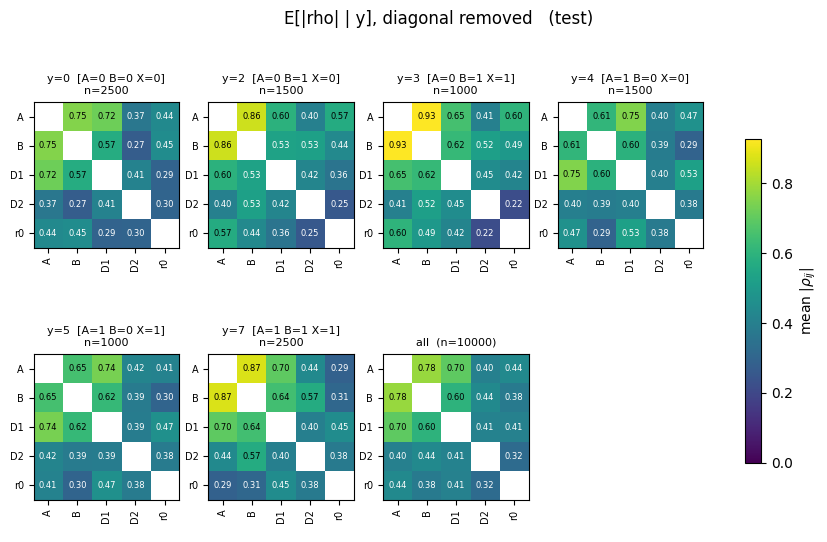

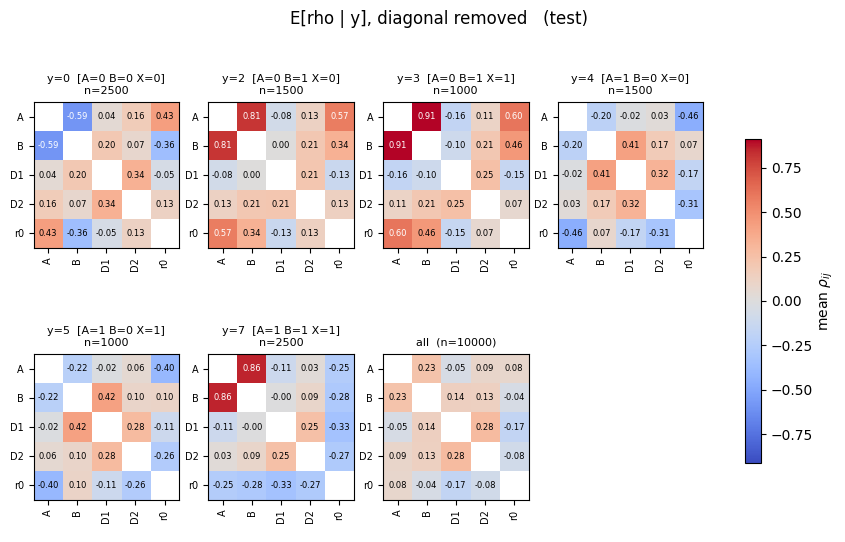

In [144]:
# rho is from section 6: rho = Sigma / (sd (x) sd), per sample, [N, C+R, C+R].
per_class_rho = {k: np.abs(rho[y_true == k]).mean(0) for k in present}
per_class_rho["all"] = np.abs(rho).mean(0)

per_class_rho_signed = {k: rho[y_true == k].mean(0) for k in present}
per_class_rho_signed["all"] = rho.mean(0)

# Relative, not absolute: a global Sigma still comes back off disk with ~1e-4 of float
# noise on it (5e-4 of mean |Sigma| for this run), so the `sigma_spread < 1e-8` test used
# in sections 3 and 6 never fires and quietly lets you stratify numerical noise. The
# amortized companion run sits at 2.3 by this measure, three orders of magnitude away.
sigma_rel_spread = sigma_spread / np.abs(Sigma).mean()
print(f"Sigma spread across samples, relative to mean |Sigma|: {sigma_rel_spread:.2e}")
if sigma_rel_spread < 1e-2:
    print("cov_type=global: Sigma, and so rho, is the same matrix for every sample -- every")
    print("panel below is that one matrix, and only the 'all' panel carries information.")

plot_class_covariances(per_class_rho, True,
                       f"E[|rho| | y], diagonal removed   ({SPLIT})",
                       cbar_label=r"mean $|\rho_{ij}|$")
plt.show()

plot_class_covariances(per_class_rho_signed, True,
                       f"E[rho | y], diagonal removed   ({SPLIT})",
                       cbar_label=r"mean $\rho_{ij}$", signed=True)
plt.show()


## What to conclude

In order — each step is only meaningful if the one before it passed:

1. **Settings** (§3): `block_diagonal_cov=False`, a learning `cov_type`, `reg_weight=0`,
   and `L_int_ext` off. A confound here invalidates everything downstream.
2. **Sigma is alive** (§3): mean concept variance well above zero. If it collapsed, raise
   `corruption_strength` and retrain — a flat cross-block from a collapsed Sigma is
   indistinguishable from a real negative and means something entirely different.
3. **Concept accuracy near 0.85** (§4): above ~0.95 and the encoder is too confident for
   the covariance to carry anything.
4. **The residual holds X** (§5): the residual-only probe clears the concept-only ceiling.
5. **The cross-block points at A and B** (§6): the parent/distractor ratio.
6. **The ratio has a scale** (§7): calibrated against the null and, better, the swap run.

If 1–4 pass and 5 comes out flat, that is a real negative about the architecture and worth
reporting as one. If 1–4 fail, 5 tells you nothing either way.